In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon

# Definisi koordinat batas wilayah (Manyar) menggunakan GeoJSON
geojson_coords = [
     [
              112.6124555,
              -7.1337934
            ],
            [
              112.6033317,
              -7.1496527
            ],
            [
              112.6203805,
              -7.1596966
            ],
            [
              112.63683,
              -7.1370975
            ],
            [
              112.6124555,
              -7.1337934
            ]
    ]

# Konversi ke bentuk Poligon
area_polygon = Polygon(geojson_coords)

# Mendapatkan koordinat pusat (centroid) untuk API
centroid_lon = area_polygon.centroid.x
centroid_lat = area_polygon.centroid.y
print(f"Titik Pusat Penarikan Data -> Latitude: {centroid_lat:.5f}, Longitude: {centroid_lon:.5f}")

Titik Pusat Penarikan Data -> Latitude: -7.14510, Longitude: 112.61904


In [2]:
import folium

# Membuat peta terpusat di centroid wilayah kajian
peta_wilayah = folium.Map(location=[centroid_lat, centroid_lon], zoom_start=13)

# Menambahkan poligon batas wilayah Manyar ke peta
folium.Polygon(
    locations=[(lat, lon) for lon, lat in geojson_coords],
    color='#e74c3c',
    weight=3,
    fill=True,
    fill_opacity=0.2,
    tooltip='Batas Wilayah Kajian - Manyar'
).add_to(peta_wilayah)

# Menandai titik pusat (centroid) tempat data ditarik
folium.Marker(
    location=[centroid_lat, centroid_lon],
    popup='Titik Pengambilan Data API',
    icon=folium.Icon(color='blue', icon='cloud')
).add_to(peta_wilayah)

peta_wilayah

In [3]:
csv_mentah = "polutan_Manyar_2025_2026.csv"
df = pd.read_csv(csv_mentah)
df['time'] = pd.to_datetime(df['time'])

print(f"Data berhasil dimuat dari: {csv_mentah}")
print(f"Rentang waktu: {df['time'].min()} s/d {df['time'].max()}")
print(f"Jumlah baris: {len(df)}")
df.head()

Data berhasil dimuat dari: polutan_Manyar_2025_2026.csv
Rentang waktu: 2025-08-31 00:00:00 s/d 2026-08-30 00:00:00
Jumlah baris: 365


,time,NO2,CO,SO2
0,2025-08-31,0.000049,0.028270,-0.000076
1,2025-09-01,0.000045,0.023488,0.000058
2,2025-09-02,0.000038,0.025977,0.000202
3,2025-09-03,0.000079,0.026092,0.000017
4,2025-09-04,0.000060,0.027812,0.000649


In [4]:
# --- Eksplorasi awal sebelum pembersihan (lihat penjelasan Bagian 2.4) ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    365 non-null    datetime64[ns]
 1   NO2     314 non-null    float64       
 2   CO      314 non-null    float64       
 3   SO2     314 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 11.5 KB


In [5]:
df.describe()

,time,NO2,CO,SO2
count,365,314.000000,314.000000,314.000000
mean,2026-03-01 00:00:00.000000256,0.000076,0.028943,0.000113
min,2025-08-31 00:00:00,0.000015,0.011331,-0.001086
25%,2025-11-30 00:00:00,0.000045,0.026625,-0.000065
50%,2026-03-01 00:00:00,0.000064,0.029021,0.000080
75%,2026-05-31 00:00:00,0.000092,0.030905,0.000279
max,2026-08-30 00:00:00,0.000631,0.043723,0.001213
std,NaN,0.000057,0.003892,0.000290


In [6]:
# Cek jumlah missing values (NaN) di setiap kolom
print("Jumlah data kosong (missing values) per kolom:")
print(df.isna().sum())

Jumlah data kosong (missing values) per kolom:
time     0
NO2     51
CO      51
SO2     51
dtype: int64


In [7]:
# Cek jumlah nilai negatif per kolom SEBELUM dibersihkan
kolom_polutan = ['CO', 'NO2', 'SO2']
for col in kolom_polutan:
    jumlah_negatif = (df[col] < 0).sum()
    print(f"Jumlah nilai negatif pada {col}: {jumlah_negatif}")

Jumlah nilai negatif pada CO: 0
Jumlah nilai negatif pada NO2: 0
Jumlah nilai negatif pada SO2: 113


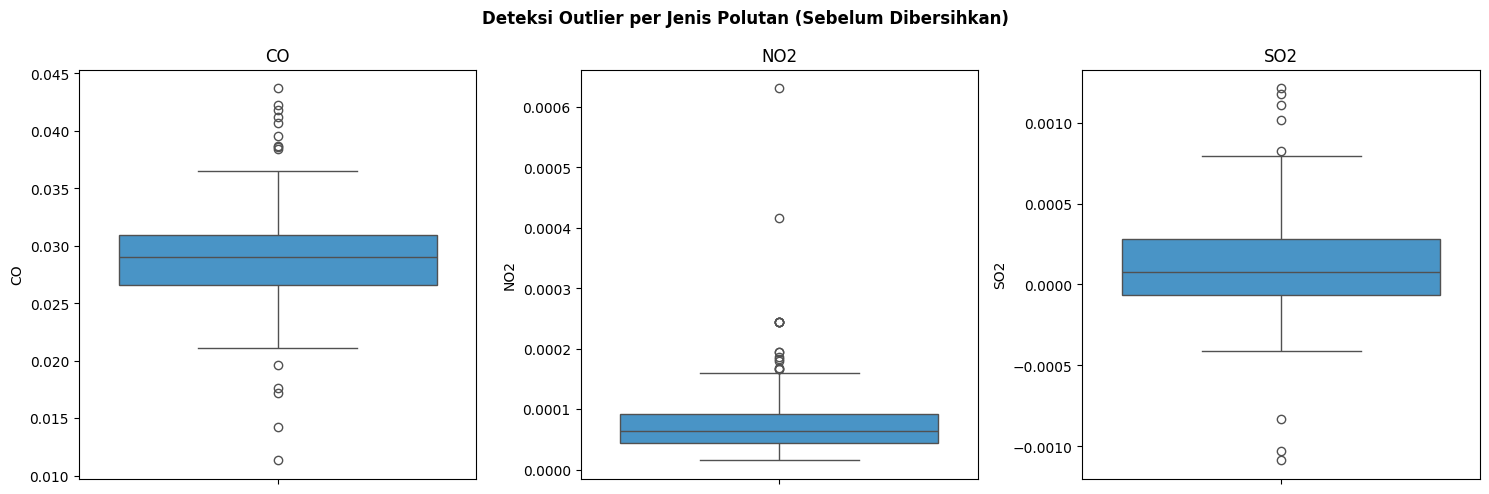

In [8]:
# Deteksi outlier ekstrem menggunakan visualisasi boxplot per kolom polutan (SEBELUM dibersihkan)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(kolom_polutan):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sebelum Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
for col in ['CO', 'NO2', 'SO2']:
    df.loc[df[col] < 0, col] = None

In [10]:
# Mengisi missing values (NaN) menggunakan interpolasi linear berbasis waktu
# Interpolasi dipilih karena data bersifat time-series dan nilai polutan
# cenderung berubah secara gradual antar-hari, bukan melompat drastis
#
# CATATAN PENTING: method='time' saja TIDAK bisa mengisi NaN yang berada di
# ujung awal atau ujung akhir deret waktu (leading/trailing NaN), karena tidak
# ada titik data di salah satu sisinya untuk diinterpolasi. Oleh karena itu
# ditambahkan limit_direction='both' agar NaN di kedua ujung juga tertangani
# (menggunakan nilai valid terdekat sebagai isian/extrapolasi sederhana).
df = df.set_index('time')
kolom_gas_tersedia = ['CO', 'NO2', 'SO2']
df[kolom_gas_tersedia] = df[kolom_gas_tersedia].interpolate(
    method='time', limit_direction='both'
)
df = df.reset_index()

# Verifikasi ulang tidak ada lagi missing values setelah interpolasi
print("Sisa missing values setelah interpolasi:")
print(df.isna().sum())

Sisa missing values setelah interpolasi:
time    0
NO2     0
CO      0
SO2     0
dtype: int64


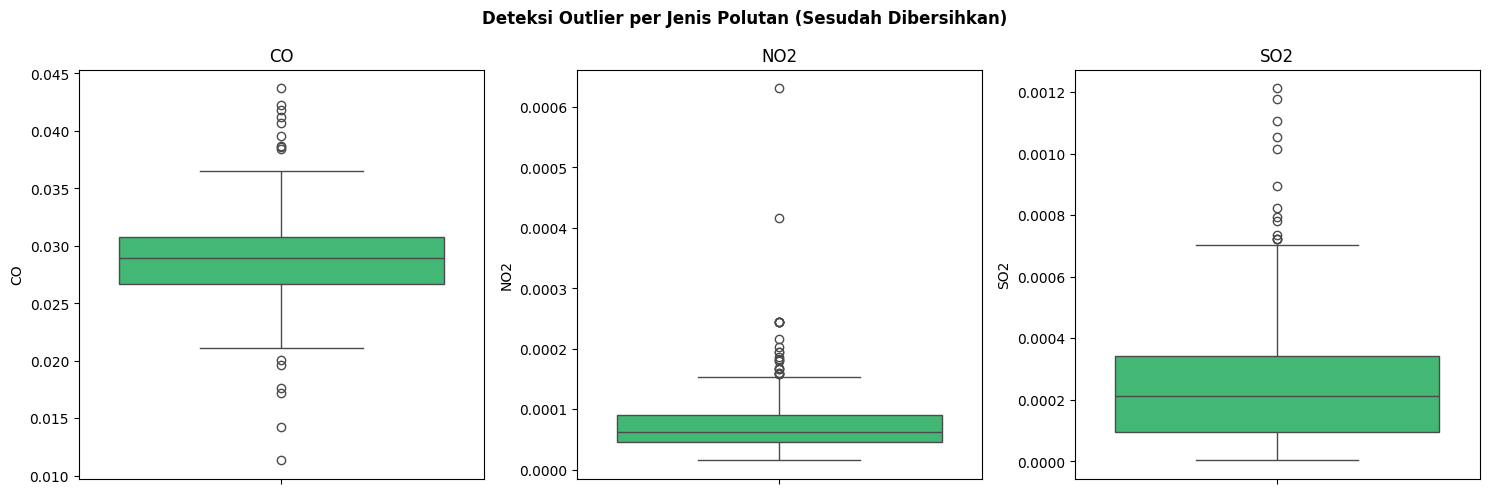

In [11]:
# Deteksi outlier SESUDAH dibersihkan, sebagai pembanding terhadap boxplot sebelumnya.
kolom_polutan_bersih = ['CO', 'NO2', 'SO2']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(kolom_polutan_bersih):
    sns.boxplot(y=df[col], ax=axes[i], color='#2ecc71')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sesudah Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()

# Catatan interpretasi: outlier yang masih tersisa setelah pembersihan nilai
# negatif tidak serta-merta dihapus, karena bisa jadi merupakan kejadian nyata
# (misalnya lonjakan akibat kebakaran lahan/kemacetan ekstrem), bukan
# error pengukuran. Outlier semacam ini dibiarkan dalam data namun dicatat
# sebagai catatan analisis lanjutan.

In [12]:
df = df.sort_values(by='time', ascending=True).reset_index(drop=True)

In [13]:
# Disimpan dengan nama berbeda dari CSV mentah hasil crawling (polutan_Manyar_2025_2026.csv)
# supaya data mentah dan data yang sudah dibersihkan tetap bisa dibedakan/ditelusuri.
csv_filename_bersih = "polutan_Manyar_2025_2026_bersih.csv"
df.to_csv(csv_filename_bersih, index=False)
print(f"Data yang sudah dibersihkan disimpan ke dalam bentuk file: {csv_filename_bersih}")

Data yang sudah dibersihkan disimpan ke dalam bentuk file: polutan_Manyar_2025_2026_bersih.csv


In [14]:
df.head()

,time,NO2,CO,SO2
0,2025-08-31,0.000049,0.028270,0.000058
1,2025-09-01,0.000045,0.023488,0.000058
2,2025-09-02,0.000038,0.025977,0.000202
3,2025-09-03,0.000079,0.026092,0.000017
4,2025-09-04,0.000060,0.027812,0.000649


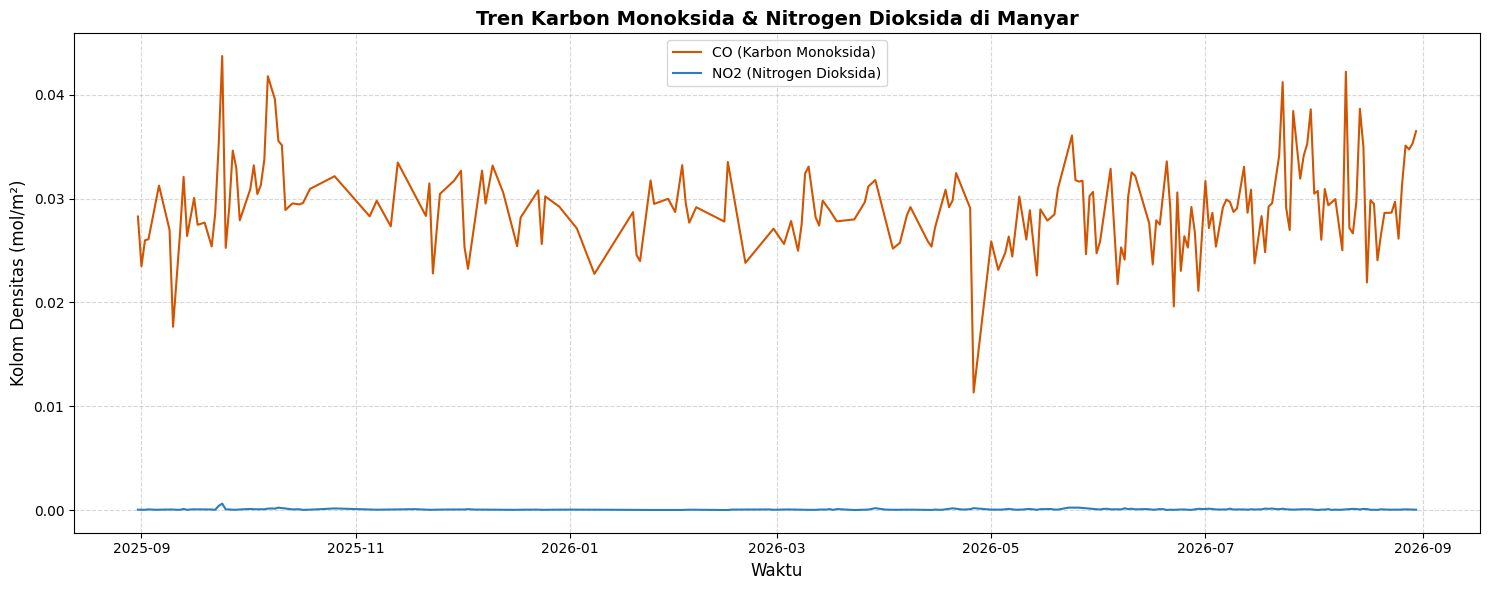

In [15]:
plt.figure(figsize=(15, 6))

# Plot Garis untuk Karbon Monoksida dan Nitrogen Dioksida
sns.lineplot(data=df, x='time', y='CO', label='CO (Karbon Monoksida)', color='#d35400')
sns.lineplot(data=df, x='time', y='NO2', label='NO2 (Nitrogen Dioksida)', color='#2980b9')

# Styling Grafik
plt.title('Tren Karbon Monoksida & Nitrogen Dioksida di Manyar', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Kolom Densitas (mol/m²)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

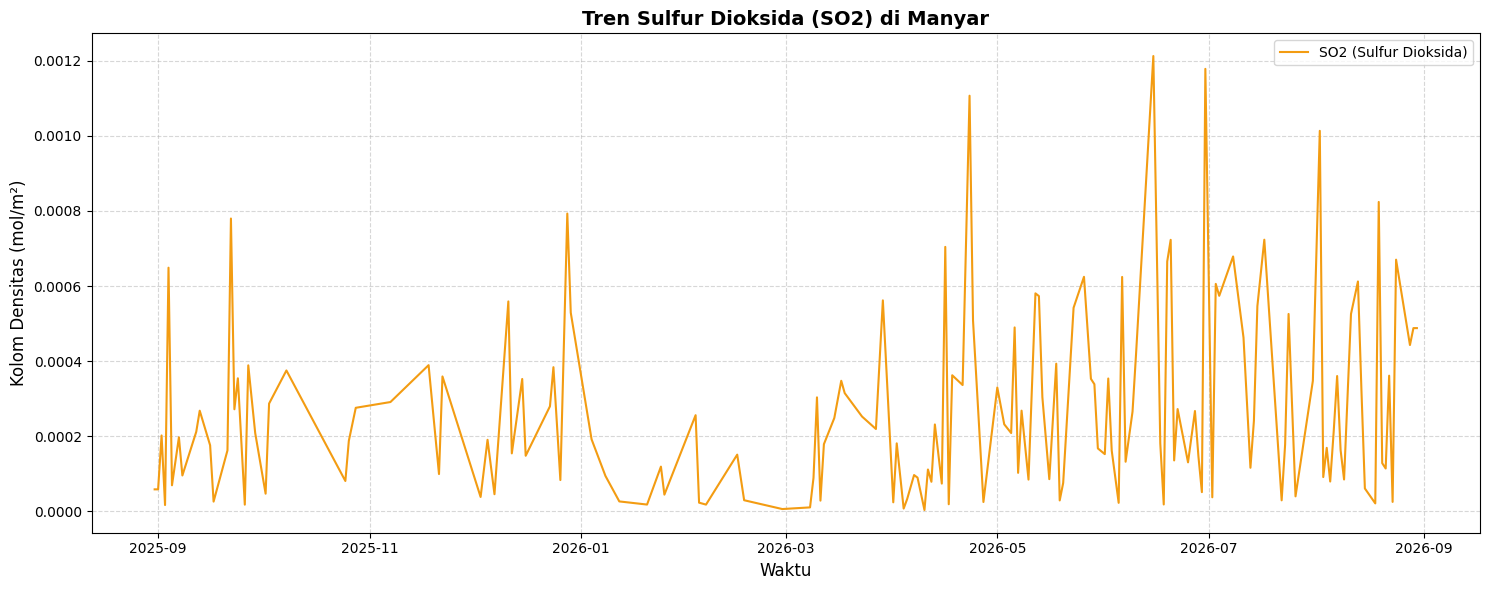

In [16]:
plt.figure(figsize=(15, 6))

sns.lineplot(data=df, x='time', y='SO2', label='SO2 (Sulfur Dioksida)', color='#f39c12')

plt.title('Tren Sulfur Dioksida (SO2) di Manyar', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Kolom Densitas (mol/m²)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

C:\Users\OKAN\AppData\Local\Temp\ipykernel_10792\4280966595.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M', on='time').mean(numeric_only=True).reset_index()


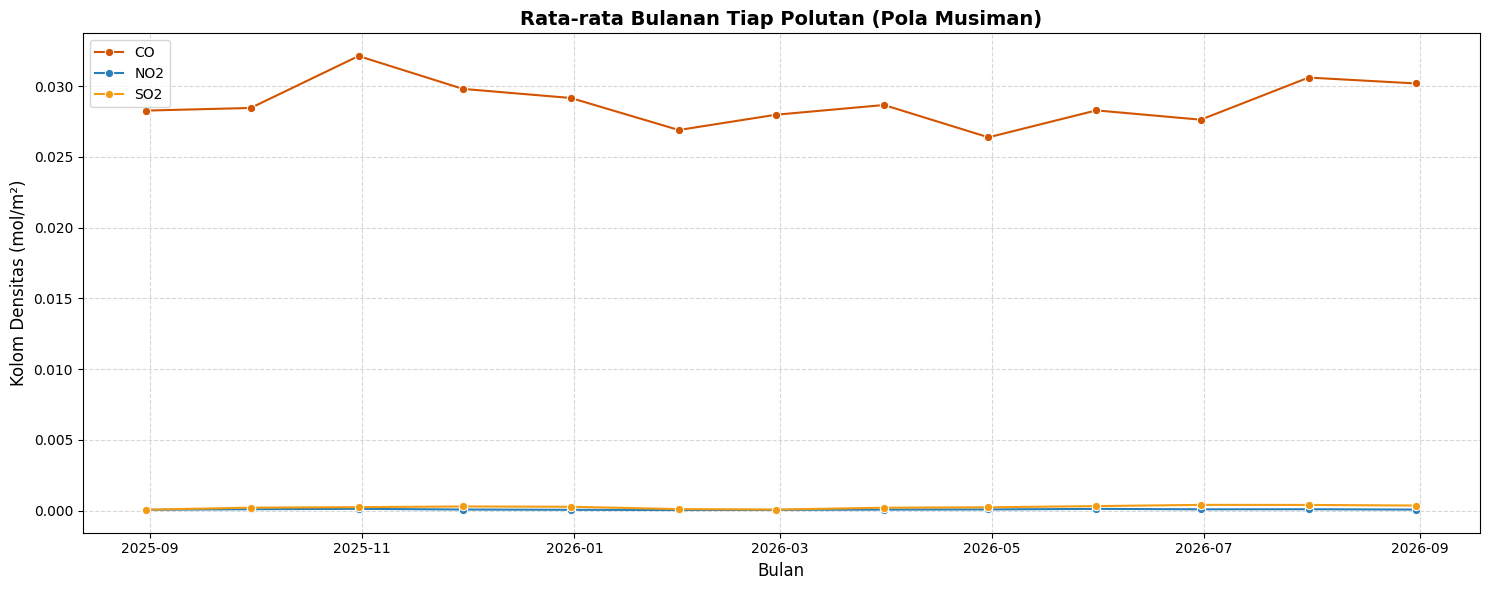

In [17]:
# Resample menjadi rata-rata bulanan untuk melihat tren musiman
df_monthly = df.resample('M', on='time').mean(numeric_only=True).reset_index()

plt.figure(figsize=(15, 6))
for col, color in zip(['CO', 'NO2', 'SO2'],
                       ['#d35400', '#2980b9', '#f39c12']):
    sns.lineplot(data=df_monthly, x='time', y=col, label=col, color=color, marker='o')

plt.title('Rata-rata Bulanan Tiap Polutan (Pola Musiman)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Kolom Densitas (mol/m²)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
# Klasifikasi musim: Kemarau (Apr-Okt) vs Hujan (Nov-Mar), pola umum Jawa Timur
def klasifikasi_musim(bulan):
    return 'Kemarau' if bulan in [4, 5, 6, 7, 8, 9, 10] else 'Hujan'

df['musim'] = df['time'].dt.month.apply(klasifikasi_musim)

# Perbandingan rata-rata konsentrasi tiap polutan antar musim
perbandingan_musim = df.groupby('musim')[['CO', 'NO2', 'SO2']].mean()
print("Rata-rata konsentrasi polutan per musim:")
perbandingan_musim

Rata-rata konsentrasi polutan per musim:


,CO,NO2,SO2
musim,,,
Hujan,0.028502,0.000053,0.000185
Kemarau,0.029108,0.000092,0.000303


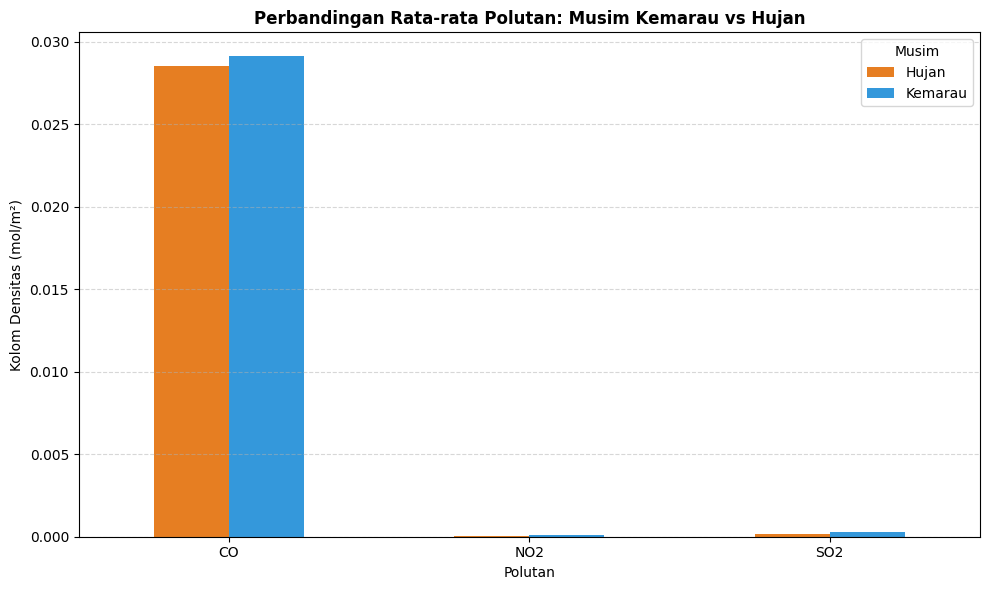

In [19]:
perbandingan_musim.T.plot(kind='bar', figsize=(10, 6), color=['#e67e22', '#3498db'])
plt.title('Perbandingan Rata-rata Polutan: Musim Kemarau vs Hujan', fontweight='bold')
plt.ylabel('Kolom Densitas (mol/m²)')
plt.xlabel('Polutan')
plt.xticks(rotation=0)
plt.legend(title='Musim')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
# Ambang referensi statistik: persentil ke-90 dari data masing-masing polutan
# (bukan baku mutu resmi, karena tidak ada standar nasional untuk kolom densitas atmosfer)
kolom_gas = ['CO', 'NO2', 'SO2']
ambang_referensi = {col: df[col].quantile(0.90) for col in kolom_gas}

hasil_pelanggaran = []
for polutan, batas in ambang_referensi.items():
    jumlah_lewat = (df[polutan] > batas).sum()
    total_data = df[polutan].notna().sum()
    persen_lewat = (jumlah_lewat / total_data) * 100 if total_data > 0 else 0
    hasil_pelanggaran.append({
        'Polutan': polutan,
        'Ambang Referensi P90 (mol/m²)': round(batas, 6),
        'Jumlah Hari Melebihi': jumlah_lewat,
        'Persentase Hari Melebihi (%)': round(persen_lewat, 2)
    })

df_pelanggaran = pd.DataFrame(hasil_pelanggaran).sort_values(
    by='Persentase Hari Melebihi (%)', ascending=False
).reset_index(drop=True)

print("Ringkasan frekuensi hari dengan kolom densitas tinggi (di atas persentil ke-90) per polutan:")
df_pelanggaran

Ringkasan frekuensi hari dengan kolom densitas tinggi (di atas persentil ke-90) per polutan:


,Polutan,Ambang Referensi P90 (mol/m²),Jumlah Hari Melebihi,Persentase Hari Melebihi (%)
0,CO,0.032771,37,10.14
1,NO2,0.000133,37,10.14
2,SO2,0.000572,37,10.14


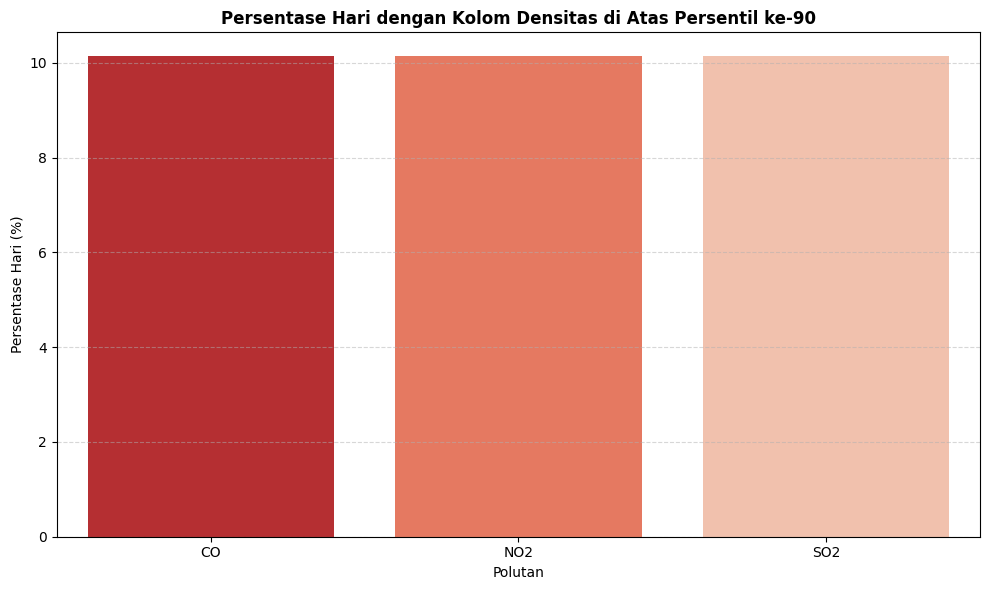

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_pelanggaran, x='Polutan', y='Persentase Hari Melebihi (%)',
            hue='Polutan', palette='Reds_r', legend=False)
plt.title('Persentase Hari dengan Kolom Densitas di Atas Persentil ke-90', fontweight='bold')
plt.ylabel('Persentase Hari (%)')
plt.xlabel('Polutan')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
# Ringkasan statistik harian dari seluruh polutan setelah proses pembersihan
df[['CO', 'NO2', 'SO2']].describe()

,CO,NO2,SO2
count,365.000000,365.000000,365.000000
mean,0.028857,0.000076,0.000254
std,0.003732,0.000055,0.000214
min,0.011331,0.000015,0.000003
25%,0.026708,0.000045,0.000094
50%,0.028897,0.000062,0.000211
75%,0.030774,0.000090,0.000340
max,0.043723,0.000631,0.001213
